In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer_data-task 2.csv", sep=';',decimal=',')
df.head()

,Customer ID,CustomerName,Age,Gender,Location,CustomerSince,Last Purchase Date,Number Of Orders,Purchase Frequency,Average Order Value,Total Spend,Favorite Category,Preferred Channel,Payment Method,Discount Used,Returned Items,Loyalty Member
0,1,Noah Johnson,20,Female,Bilbao,2025-06-02,2026-02-13,6,6,196.86,1181.16,Sports,Mobile App,Bank Transfer,Yes,1,Yes
1,2,Liam Smith,45,Male,Bilbao,2022-03-23,2025-09-16,22,22,181.39,3990.58,Beauty,Website,Credit Card,No,5,No
2,3,Liam Smith,36,Female,Bilbao,2024-11-11,2026-06-08,6,6,173.44,1040.64,Beauty,Mobile App,Apple Pay,Yes,2,No
3,4,James Taylor,54,Female,Madrid,2020-02-27,2025-10-26,14,14,208.89,2924.46,Beauty,Physical Store,Google Pay,No,5,No
4,5,John Brown,64,Male,Seville,2020-03-02,2025-07-23,27,27,106.14,2865.78,Books,Mobile App,PayPal,No,2,No


In [56]:
df.info()
df_copy = df

<class 'pandas.DataFrame'>
MultiIndex: 300 entries, ('1;Noah Johnson;20;Female;Bilbao;2025-06-02;2026-02-13;6;6;196', '86;1181') to ('300;John Brown;53;Other;Madrid;2024-06-30;2026-01-07;11;11;179', '47;1974')
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                            Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                            --------------  -----
 0   Customer ID;CustomerName;Age;Gender;Location;CustomerSince;Last Purchase Date;Number Of Orders;Purchase Frequency;Average Order Value;Total Spend;Favorite Category;Preferred Channel;Payment Method;Discount Used;Retu

In [5]:
grouped = df.groupby('Location')
spent_grouped = grouped['Total Spend']
spent_mean = spent_grouped.mean()
print(spent_mean)

Location
Barcelona    2943.091351
Bilbao       3019.380213
Lisbon       3103.446087
Madrid       2485.937778
Porto        2944.208478
Seville      2089.472553
Valencia     2950.950488
Name: Total Spend, dtype: float64


In [12]:
print(f'The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')





The dataset contains 300 rows and 17 columns.


In [20]:
df.columns = df.columns.str.strip().str.replace('_','', regex=False)
for col in df.columns:
    print(col)

CustomerID
CustomerName
Age
Gender
Location
CustomerSince
LastPurchaseDate
NumberOfOrders
PurchaseFrequency
AverageOrderValue
TotalSpend
FavoriteCategory
PreferredChannel
PaymentMethod
DiscountUsed
ReturnedItems
LoyaltyMember


In [25]:
df['CustomerID'].duplicated().sum()


np.int64(0)

In [27]:
df.dtypes

CustomerID             int64
CustomerName             str
Age                    int64
Gender                   str
Location                 str
CustomerSince            str
LastPurchaseDate         str
NumberOfOrders         int64
PurchaseFrequency      int64
AverageOrderValue    float64
TotalSpend           float64
FavoriteCategory         str
PreferredChannel         str
PaymentMethod            str
DiscountUsed             str
ReturnedItems          int64
LoyaltyMember            str
dtype: object

In [ ]:
df.isnull().sum().any()
# there are no NaN values in the df

np.False_

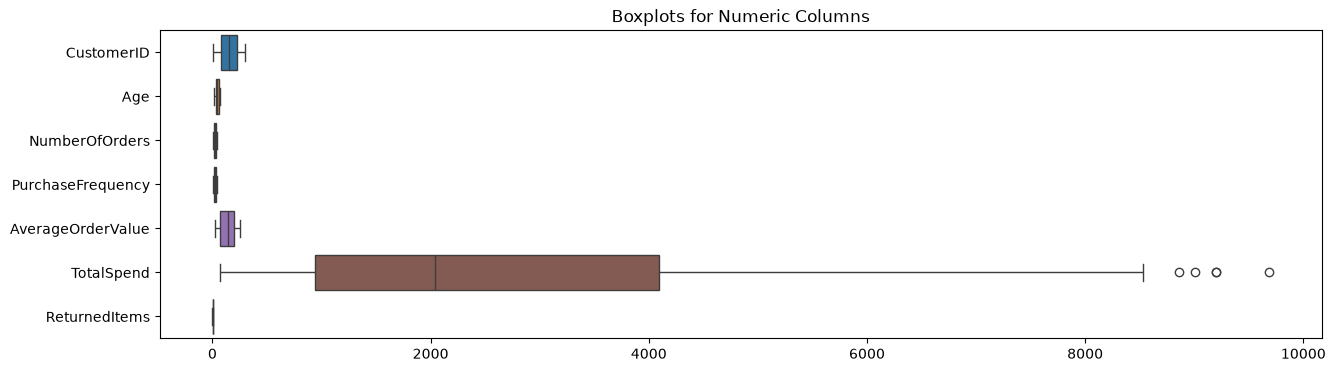

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
plt.figure(figsize=(15, 4))
sns.boxplot(data=df[numeric_columns], orient='h')
plt.title('Boxplots for Numeric Columns')
plt.show()

In [30]:
# eda
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,300.0,150.500000,86.746758,1.00,75.7500,150.500,225.2500,300.00
Age,300.0,44.623333,15.150575,18.00,32.0000,45.000,58.0000,70.00
NumberOfOrders,300.0,20.433333,11.938200,1.00,10.0000,20.000,31.0000,40.00
PurchaseFrequency,300.0,20.433333,11.938200,1.00,10.0000,20.000,31.0000,40.00
AverageOrderValue,300.0,136.423033,69.126782,21.04,69.9975,142.805,196.6200,249.98
TotalSpend,300.0,2792.284333,2285.385955,66.99,940.9625,2038.550,4095.4275,9687.20
ReturnedItems,300.0,2.556667,1.742674,0.00,1.0000,3.000,4.0000,5.00


In [31]:
df.isnull().sum()

CustomerID           0
CustomerName         0
Age                  0
Gender               0
Location             0
CustomerSince        0
LastPurchaseDate     0
NumberOfOrders       0
PurchaseFrequency    0
AverageOrderValue    0
TotalSpend           0
FavoriteCategory     0
PreferredChannel     0
PaymentMethod        0
DiscountUsed         0
ReturnedItems        0
LoyaltyMember        0
dtype: int64

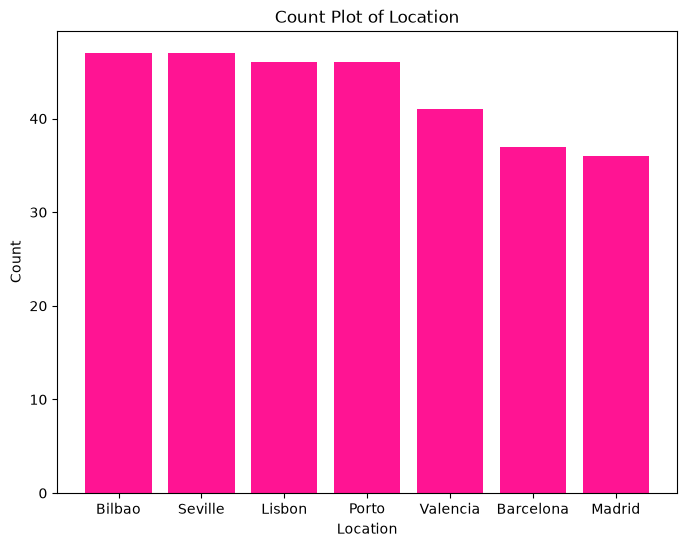

In [34]:
location_counts = df['Location'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(location_counts.index, location_counts, color='deeppink')
plt.title('Count Plot of Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

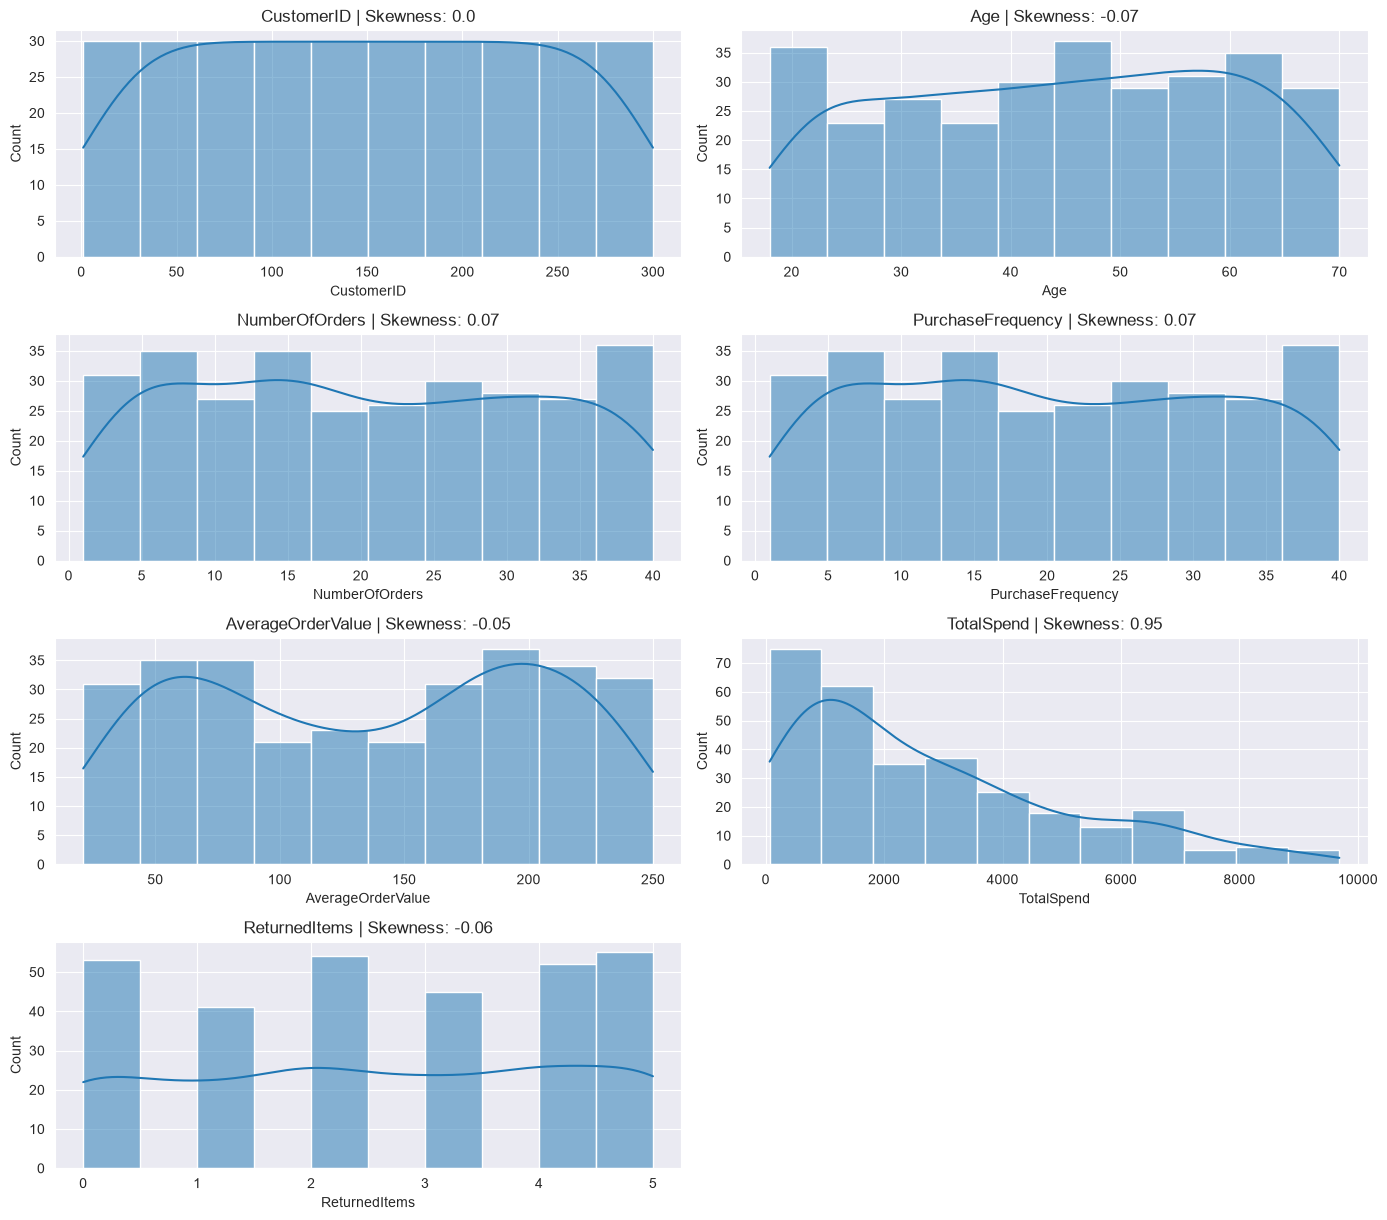

In [35]:
sns.set_style("darkgrid")

plt.figure(figsize=(14, len(numeric_columns) * 3))
for idx, feature in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14988\2313596835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Location", y="TotalSpend", data=df, palette='viridis')


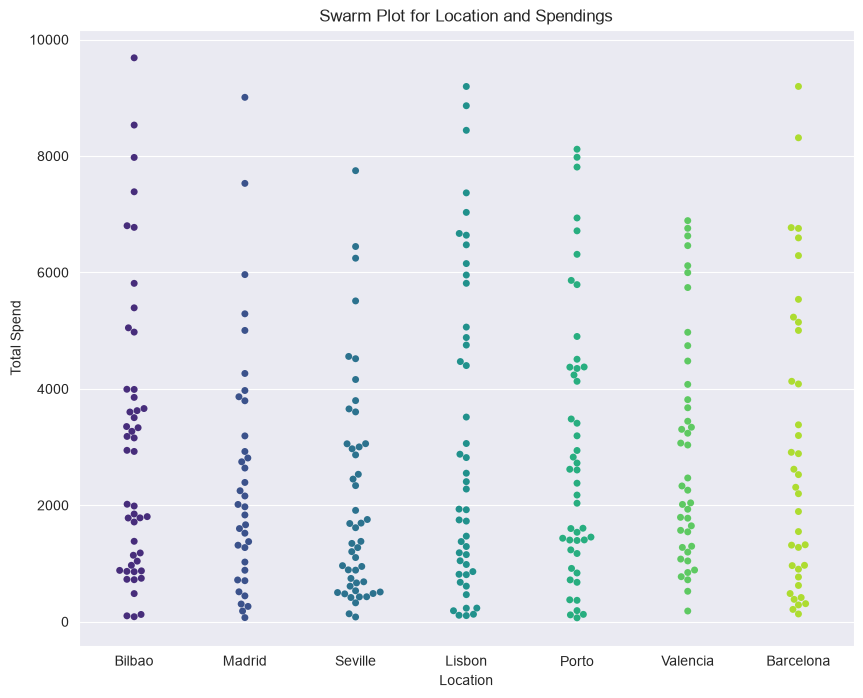

In [37]:
plt.figure(figsize=(10, 8))

sns.swarmplot(x="Location", y="TotalSpend", data=df, palette='viridis')

plt.title('Swarm Plot for Location and Spendings')
plt.xlabel('Location')
plt.ylabel('Total Spend')
plt.show()

<Figure size 1000x600 with 0 Axes>

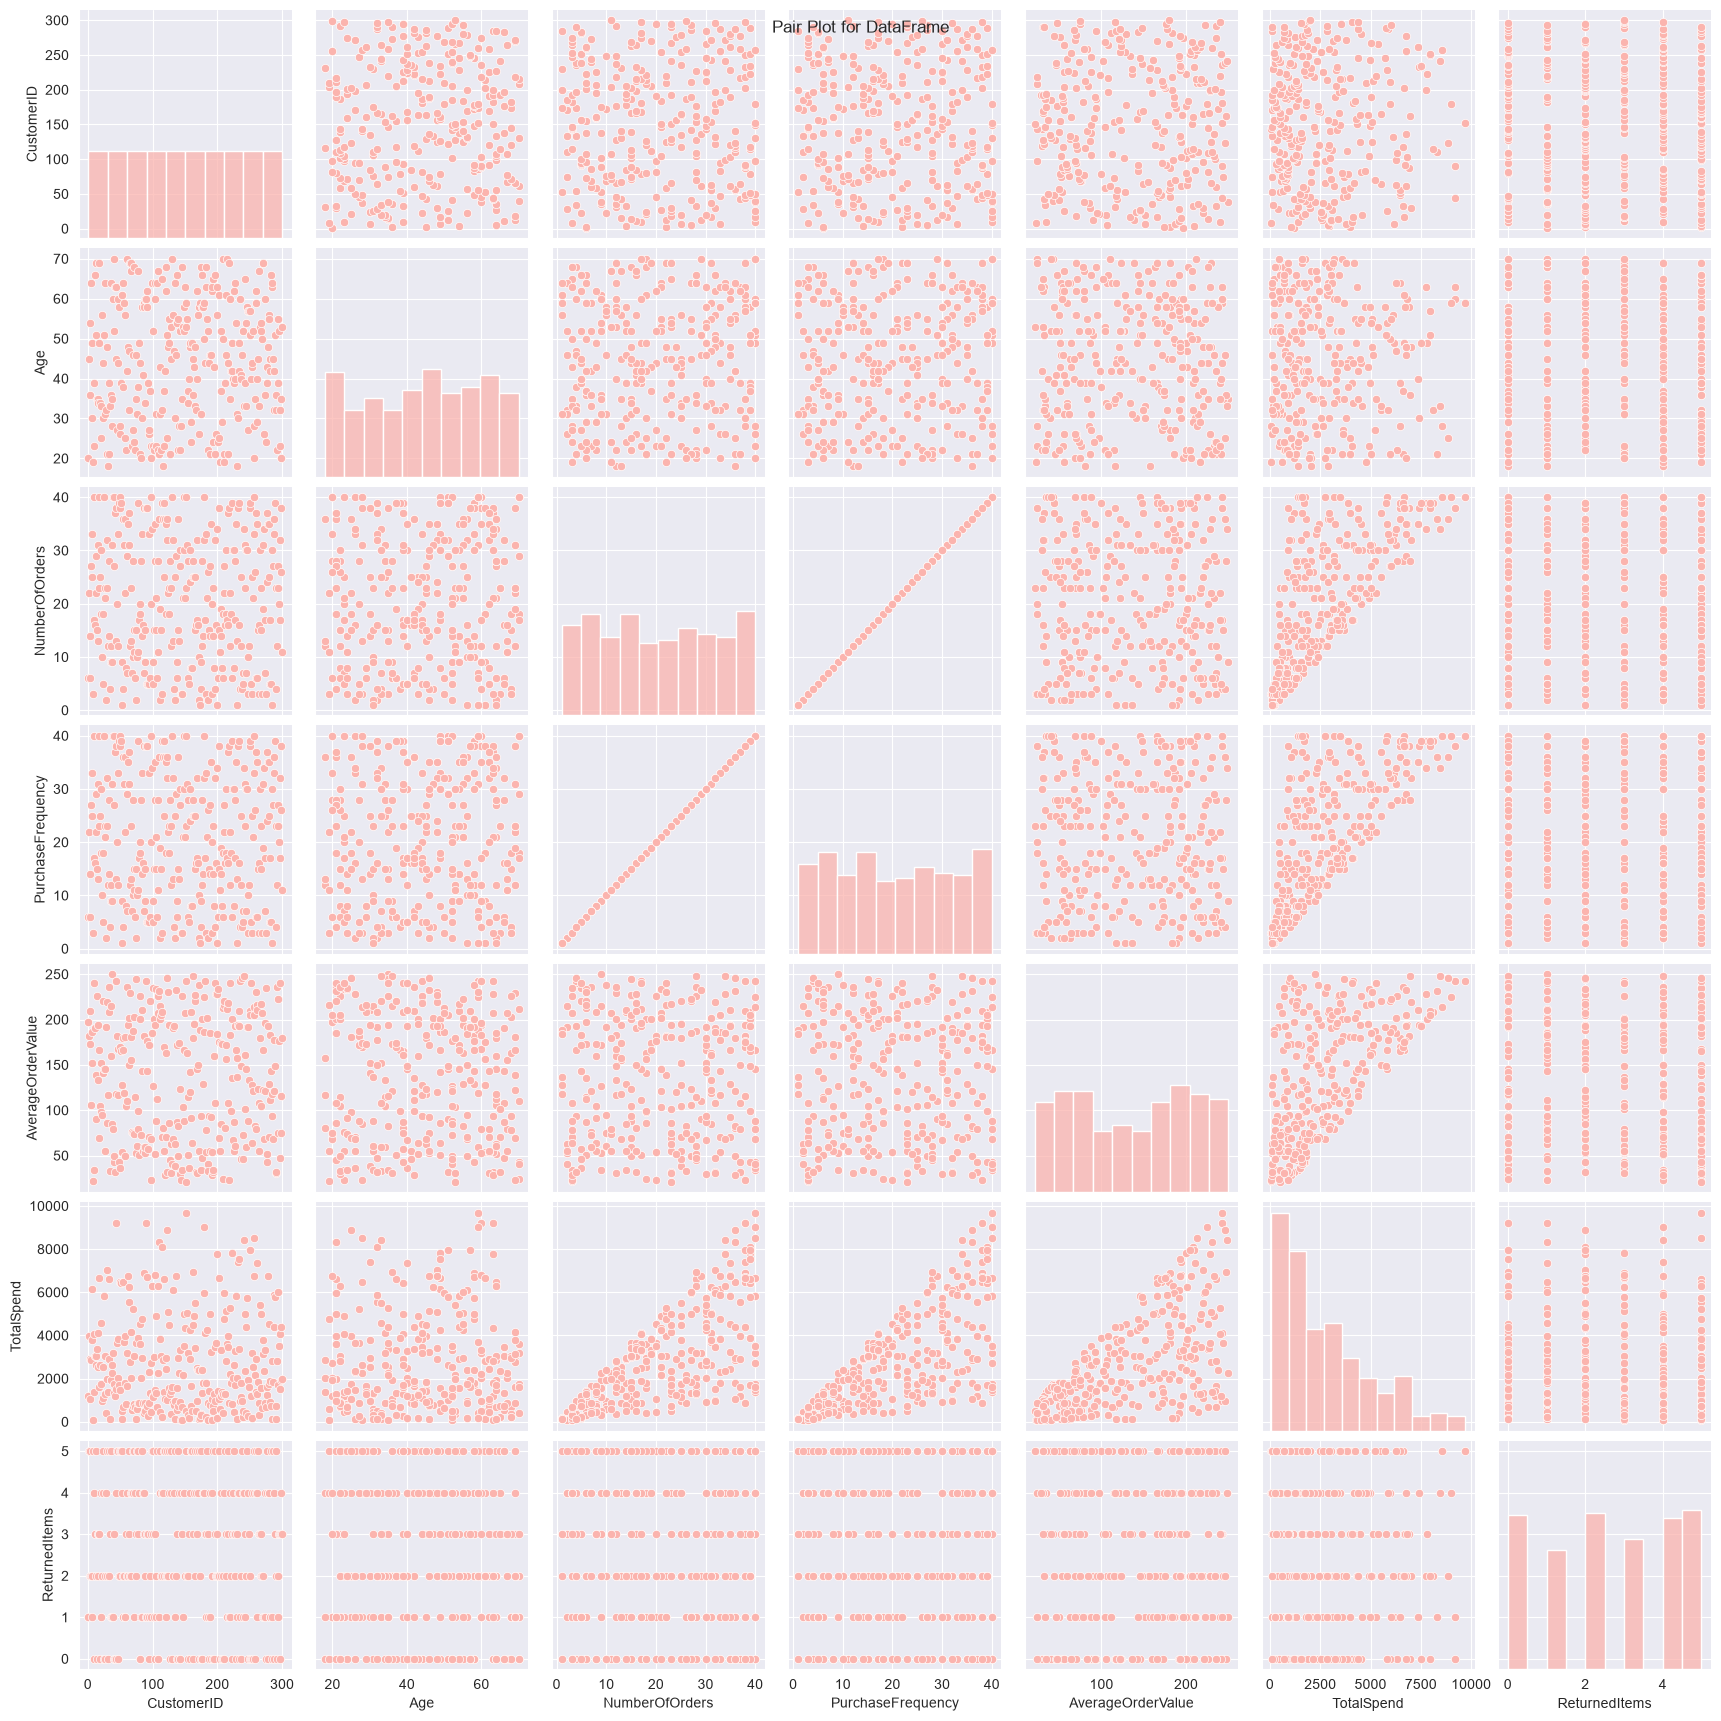

In [38]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

<Axes: xlabel='Location', ylabel='AverageOrderValue'>

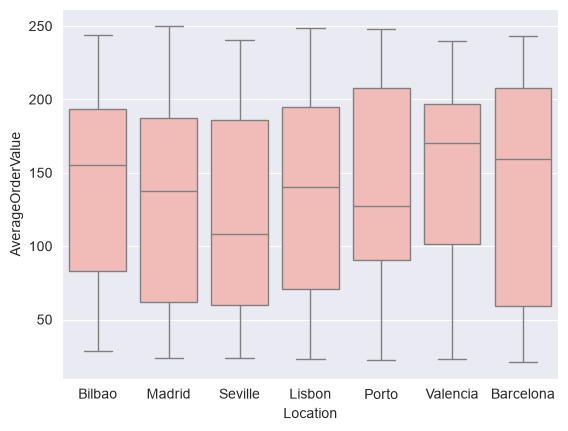

In [39]:
sns.boxplot(x='Location', y='AverageOrderValue', data=df)

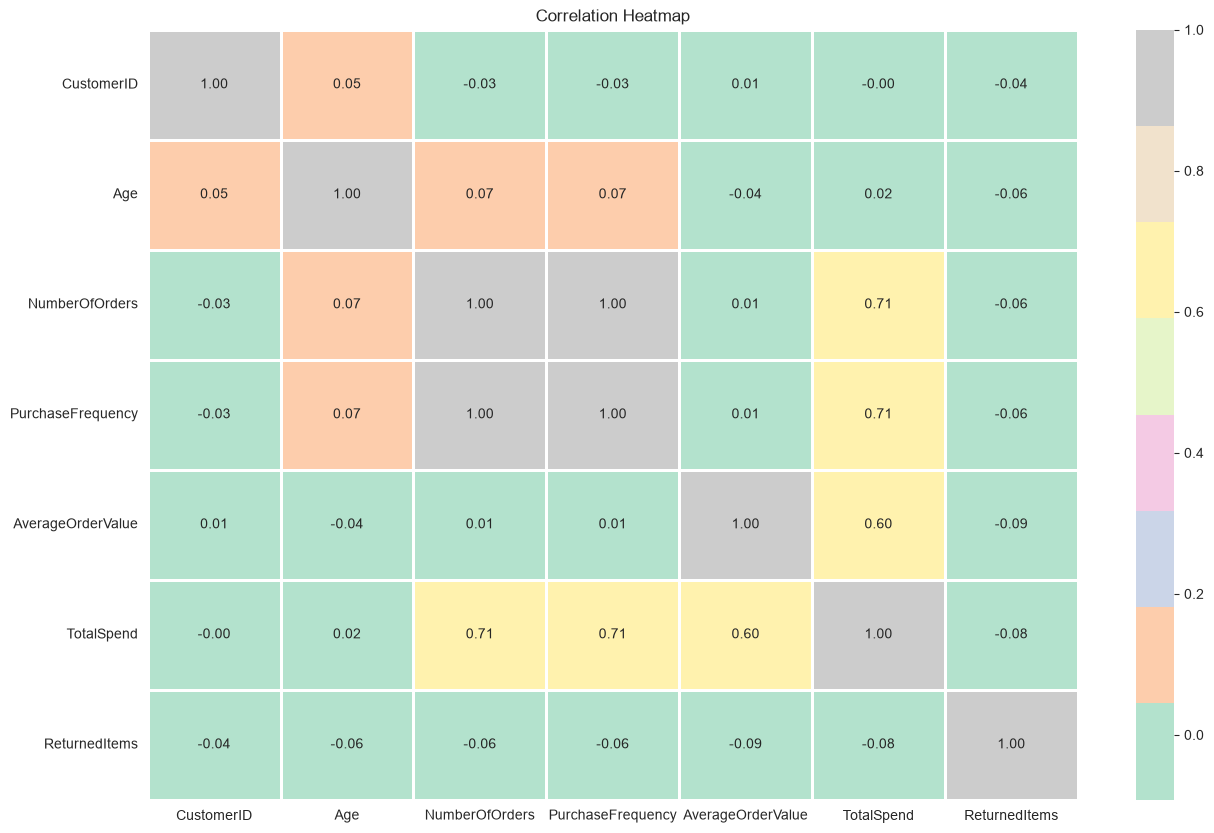

In [43]:
plt.figure(figsize=(15, 10))

sns.heatmap(df[numeric_columns].corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# customer segmentation/ clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [57]:
df = pd.read_csv("customer_data-task 2.csv", sep=';',decimal=',')
df.head()

# Explore first
print(df.head())
print(df.dtypes)
print(df['Location'].nunique())  # How many unique locations?
print(df['Gender'].nunique())    # How many unique genders?

   Customer ID  CustomerName  Age  Gender Location CustomerSince  \
0            1  Noah Johnson   20  Female   Bilbao    2025-06-02   
1            2    Liam Smith   45    Male   Bilbao    2022-03-23   
2            3    Liam Smith   36  Female   Bilbao    2024-11-11   
3            4  James Taylor   54  Female   Madrid    2020-02-27   
4            5    John Brown   64    Male  Seville    2020-03-02   

  Last Purchase Date  Number Of Orders  Purchase Frequency  \
0         2026-02-13                 6                   6   
1         2025-09-16                22                  22   
2         2026-06-08                 6                   6   
3         2025-10-26                14                  14   
4         2025-07-23                27                  27   

   Average Order Value  Total Spend Favorite Category Preferred Channel  \
0               196.86      1181.16            Sports        Mobile App   
1               181.39      3990.58            Beauty           Webs

In [58]:
df_copy = df

In [59]:
df_copy.head()

,Customer ID,CustomerName,Age,Gender,Location,CustomerSince,Last Purchase Date,Number Of Orders,Purchase Frequency,Average Order Value,Total Spend,Favorite Category,Preferred Channel,Payment Method,Discount Used,Returned Items,Loyalty Member
0,1,Noah Johnson,20,Female,Bilbao,2025-06-02,2026-02-13,6,6,196.86,1181.16,Sports,Mobile App,Bank Transfer,Yes,1,Yes
1,2,Liam Smith,45,Male,Bilbao,2022-03-23,2025-09-16,22,22,181.39,3990.58,Beauty,Website,Credit Card,No,5,No
2,3,Liam Smith,36,Female,Bilbao,2024-11-11,2026-06-08,6,6,173.44,1040.64,Beauty,Mobile App,Apple Pay,Yes,2,No
3,4,James Taylor,54,Female,Madrid,2020-02-27,2025-10-26,14,14,208.89,2924.46,Beauty,Physical Store,Google Pay,No,5,No
4,5,John Brown,64,Male,Seville,2020-03-02,2025-07-23,27,27,106.14,2865.78,Books,Mobile App,PayPal,No,2,No


In [64]:
df_copy.columns = df_copy.columns.str.strip().str.replace(' ','', regex=False)
for col in df_copy.columns:
    print(col)

CustomerID
CustomerName
Age
Gender
Location
CustomerSince
LastPurchaseDate
NumberOfOrders
PurchaseFrequency
AverageOrderValue
TotalSpend
FavoriteCategory
PreferredChannel
PaymentMethod
DiscountUsed
ReturnedItems
LoyaltyMember


In [65]:
df_copy = df_copy.drop(['CustomerID', 'CustomerName'], axis=1)
# Convert dates to numeric (days)
df_copy['CustomerSince'] = (pd.Timestamp.now() - pd.to_datetime(df_copy['CustomerSince'])).dt.days
df_copy['LastPurchaseDate'] = (pd.Timestamp.now() - pd.to_datetime(df_copy['LastPurchaseDate'])).dt.days

In [66]:
df_copy.head()

,Age,Gender,Location,CustomerSince,LastPurchaseDate,NumberOfOrders,PurchaseFrequency,AverageOrderValue,TotalSpend,FavoriteCategory,PreferredChannel,PaymentMethod,DiscountUsed,ReturnedItems,LoyaltyMember
0,20,Female,Bilbao,419,163,6,6,196.86,1181.16,Sports,Mobile App,Bank Transfer,Yes,1,Yes
1,45,Male,Bilbao,1586,313,22,22,181.39,3990.58,Beauty,Website,Credit Card,No,5,No
2,36,Female,Bilbao,622,48,6,6,173.44,1040.64,Beauty,Mobile App,Apple Pay,Yes,2,No
3,54,Female,Madrid,2341,273,14,14,208.89,2924.46,Beauty,Physical Store,Google Pay,No,5,No
4,64,Male,Seville,2337,368,27,27,106.14,2865.78,Books,Mobile App,PayPal,No,2,No


In [ ]:
# Convert binary columns to 0/1
df_copy['LoyaltyMember'] = df_copy['LoyaltyMember'].map({'Yes': 1, 'No': 0})
df_copy['DiscountUsed'] = df_copy['DiscountUsed'].map({'Yes': 1, 'No': 0})




In [68]:
categorical_columns = ['Gender', 'Location', 'FavoriteCategory', 'PreferredChannel', 'PaymentMethod']

In [69]:
from sklearn.preprocessing import LabelEncoder

def label_encode_columns(df, columns_to_encode):
    """
    Converts specified categorical variables in a DataFrame to label-encoded values.
    """
    
    label_encoders = {} 
    
    for column in columns_to_encode:
        if column in df.columns:
            le = LabelEncoder()
            df[column] = le.fit_transform(df[column])
            label_encoders[column] = le    # Save the label encoder for reversibility or reuse. 
        else:
            raise ValueError(f"Column '{column}' not found in the DataFrame.")
    
    return df

In [70]:
df_copy = label_encode_columns(df_copy, categorical_columns)

In [71]:
df_copy

,Age,Gender,Location,CustomerSince,LastPurchaseDate,NumberOfOrders,PurchaseFrequency,AverageOrderValue,TotalSpend,FavoriteCategory,PreferredChannel,PaymentMethod,DiscountUsed,ReturnedItems,LoyaltyMember
0,20,0,1,419,163,6,6,196.86,1181.16,5,0,1,1,1,1
1,45,1,1,1586,313,22,22,181.39,3990.58,0,2,2,0,5,0
2,36,0,1,622,48,6,6,173.44,1040.64,0,0,0,1,2,0
3,54,0,3,2341,273,14,14,208.89,2924.46,0,1,3,0,5,0
4,64,1,5,2337,368,27,27,106.14,2865.78,1,0,4,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,32,1,3,2480,355,32,32,47.52,1520.64,5,0,2,1,0,0
296,23,1,0,1503,194,17,17,240.23,4083.91,3,2,3,0,3,0
297,35,1,2,1495,67,38,38,115.80,4400.40,3,1,4,0,4,0
298,20,0,2,1275,160,26,26,74.39,1934.14,1,2,4,0,3,1


In [72]:
# scaling the data 
scaler = StandardScaler()
sf_scaled = scaler.fit_transform(df_copy)


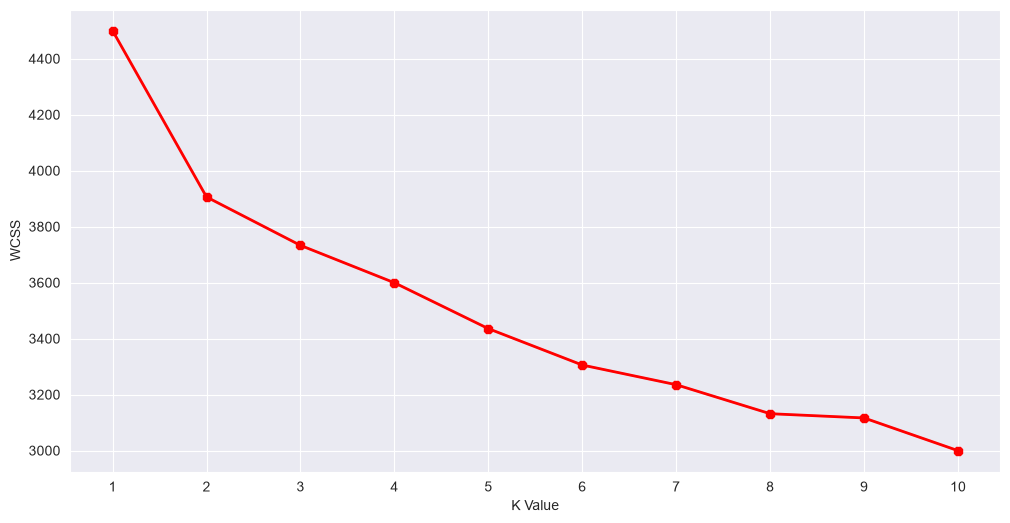

In [73]:
from sklearn.cluster import KMeans
import numpy as np

wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit(sf_scaled)
    wcss.append(km.inertia_)

# generate the elbow plot
plt.figure(figsize=(12,6))
plt.plot(range(1,11),wcss)
plt.plot(range(1,11),wcss, linewidth=2, color="red", marker ="8")
plt.xlabel("K Value")
plt.xticks(np.arange(1,11,1))
plt.ylabel("WCSS")
plt.show()


In [74]:
# taking 2 clusters
km1 = KMeans(n_clusters=2)
# fitting
km1.fit(sf_scaled)
y = km1.predict(sf_scaled)
df_copy['label'] = y
df_copy.head()

,Age,Gender,Location,CustomerSince,LastPurchaseDate,NumberOfOrders,PurchaseFrequency,AverageOrderValue,TotalSpend,FavoriteCategory,PreferredChannel,PaymentMethod,DiscountUsed,ReturnedItems,LoyaltyMember,label
0,20,0,1,419,163,6,6,196.86,1181.16,5,0,1,1,1,1,1
1,45,1,1,1586,313,22,22,181.39,3990.58,0,2,2,0,5,0,0
2,36,0,1,622,48,6,6,173.44,1040.64,0,0,0,1,2,0,1
3,54,0,3,2341,273,14,14,208.89,2924.46,0,1,3,0,5,0,1
4,64,1,5,2337,368,27,27,106.14,2865.78,1,0,4,0,2,0,0
